<a href="https://colab.research.google.com/github/OmarFarukNoman/Into-to-Machine-Learning/blob/main/Homework-6/Problem_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem - 3(a)**

Device: cpu

Number of parameters:
fc1.weight           : shape [512, 3072] = 1572864 parameters
fc1.bias             : shape [512] = 512 parameters
fc2.weight           : shape [10, 512] = 5120 parameters
fc2.bias             : shape [10] = 10 parameters

Total number of trainable parameters: 1578506


Epoch = 1
Training Loss: 1.6364, Training Accuracy: 0.4276 
Validation Loss: 1.5287, Validation Accuracy: 0.4693
Time: 24.15s 

Epoch = 2
Training Loss: 1.4386, Training Accuracy: 0.5002 
Validation Loss: 1.4341, Validation Accuracy: 0.4983
Time: 25.79s 

Epoch = 3
Training Loss: 1.3391, Training Accuracy: 0.5375 
Validation Loss: 1.4200, Validation Accuracy: 0.5034
Time: 23.82s 

Epoch = 4
Training Loss: 1.2684, Training Accuracy: 0.5634 
Validation Loss: 1.3724, Validation Accuracy: 0.5232
Time: 23.76s 

Epoch = 5
Training Loss: 1.2055, Training Accuracy: 0.5881 
Validation Loss: 1.3750, Validation Accuracy: 0.5255
Time: 24.09s 

Epoch = 6
Training Loss: 1.1515, Training Accuracy: 0.6

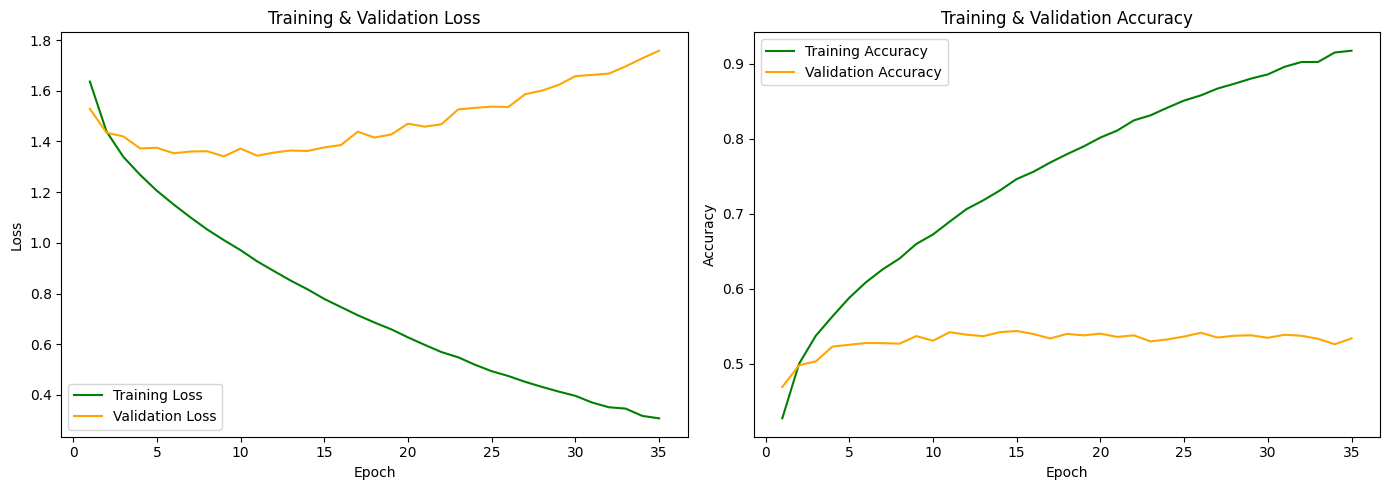

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Parameters
batch_size = 128
learning_rate = 1.15e-4
num_epochs = 35

torch.manual_seed(0)

# We're using CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Fully connected netwrok with only hidden layer
class FCNet(nn.Module):
    def __init__(self, input_dim=3*32*32, hidden_dim=512, num_classes=10):
        super(FCNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten: (batch_size, 3072)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = FCNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Model size
total_params = 0
print("\nNumber of parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        num = param.numel()
        total_params += num
        print(f"{name:20s} : shape {list(param.shape)} = {num} parameters")

print(f"\nTotal number of trainable parameters: {total_params}")
print("\n")

# I've stored the data
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Total simulation time
total_start_time = time.time()

# Training loop
for epoch in range(1, num_epochs + 1):
    epoch_start_time = time.time()

    # Training
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size_curr = labels.size(0)
        train_loss_sum += loss.item() * batch_size_curr
        train_total += batch_size_curr
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    avg_train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size_curr = labels.size(0)
            val_loss_sum += loss.item() * batch_size_curr
            val_total += batch_size_curr
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    avg_val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    # Losses and Accuracies
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    epoch_end_time = time.time()
    epoch_time = epoch_end_time - epoch_start_time

    print(
        f"Epoch = {epoch}"
        f"\nTraining Loss: {avg_train_loss:.4f}, Training Accuracy: {train_acc:.4f} "
        f"\nValidation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_acc:.4f}"
        f"\nTime: {epoch_time:.2f}s \n"
    )

# Simulation time
total_end_time = time.time()
total_sim_time = total_end_time - total_start_time
print(f"\nTotal simulation time: {total_sim_time:.2f} seconds")

# Plots
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Training Loss", color="green")
plt.plot(epochs, val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Training Accuracy", color="green")
plt.plot(epochs, val_accs, label="Validation Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


**Problem - 3(b)**

Device: cpu


100%|██████████| 170M/170M [00:01<00:00, 90.5MB/s]



Number of parameters:
fc1.weight           : shape [512, 3072] = 1572864 parameters
fc1.bias             : shape [512] = 512 parameters
fc2.weight           : shape [256, 512] = 131072 parameters
fc2.bias             : shape [256] = 256 parameters
fc3.weight           : shape [128, 256] = 32768 parameters
fc3.bias             : shape [128] = 128 parameters
fc4.weight           : shape [10, 128] = 1280 parameters
fc4.bias             : shape [10] = 10 parameters

Total number of trainable parameters: 1738890


Epoch = 1
Training Loss: 1.6732, Training Accuracy: 0.4096 
Validation Loss: 1.5258, Validation Accuracy: 0.4639
Time: 35.62s 

Epoch = 2
Training Loss: 1.4418, Training Accuracy: 0.4941 
Validation Loss: 1.4202, Validation Accuracy: 0.5019
Time: 36.32s 

Epoch = 3
Training Loss: 1.3290, Training Accuracy: 0.5358 
Validation Loss: 1.3811, Validation Accuracy: 0.5122
Time: 36.00s 

Epoch = 4
Training Loss: 1.2454, Training Accuracy: 0.5640 
Validation Loss: 1.3536, Validation Accu

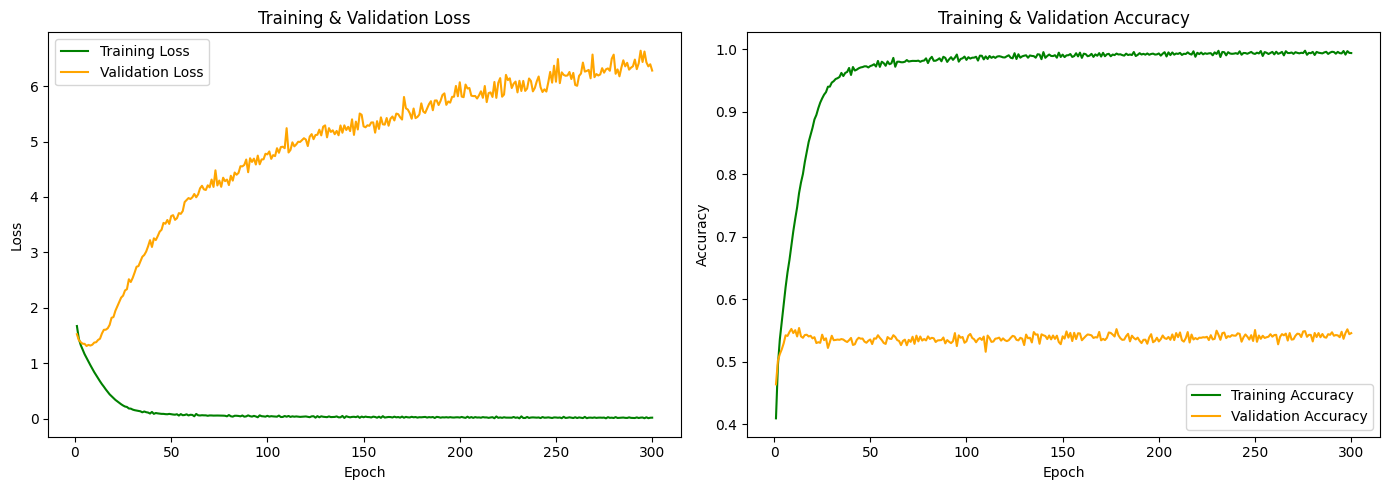

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Parameters
batch_size = 64
learning_rate = 1.15e-4
num_epochs = 300

torch.manual_seed(0)

# We're using dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Fully connected network with three hidden layers-
class FCNet(nn.Module):
    def __init__(self, input_dim=3*32*32, h1=512, h2=256, h3=128, num_classes=10):
        super(FCNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(h1, h2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(h2, h3)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(h3, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

model = FCNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Model size
total_params = 0
print("\nNumber of parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        num = param.numel()
        total_params += num
        print(f"{name:20s} : shape {list(param.shape)} = {num} parameters")

print(f"\nTotal number of trainable parameters: {total_params}")
print("\n")

# I've stored the data
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Total simulation time
total_start_time = time.time()

# Training loop
for epoch in range(1, num_epochs + 1):
    epoch_start_time = time.time()

    # Training
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size_curr = labels.size(0)
        train_loss_sum += loss.item() * batch_size_curr
        train_total += batch_size_curr
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    avg_train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # Validation (using test set here)
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size_curr = labels.size(0)
            val_loss_sum += loss.item() * batch_size_curr
            val_total += batch_size_curr
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    avg_val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    # Losses and Accuracies
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    epoch_end_time = time.time()
    epoch_time = epoch_end_time - epoch_start_time

    print(
        f"Epoch = {epoch}"
        f"\nTraining Loss: {avg_train_loss:.4f}, Training Accuracy: {train_acc:.4f} "
        f"\nValidation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_acc:.4f}"
        f"\nTime: {epoch_time:.2f}s \n"
    )

# Simulation time
total_end_time = time.time()
total_sim_time = total_end_time - total_start_time
print(f"\nTotal simulation time: {total_sim_time:.2f} seconds")

# Plots
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Training Loss", color="green")
plt.plot(epochs, val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Training Accuracy", color="green")
plt.plot(epochs, val_accs, label="Validation Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
